In [2]:
from typing import Literal
from langgraph.types import Command
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain_core.messages import AIMessage

def agent_1(state: MessagesState) -> Command[Literal["agent_2"]]:
    messages = AIMessage(content= "1번 에이전트 메시지입니다.")

    return Command(
        goto= "agent_2",
        update= {"messages": [messages]}
    )

def agent_2(state: MessagesState) -> Command[Literal[END]]:
    message= AIMessage(content= "2번 에이전트 메시지입니다.")

    return Command(
        goto= END,
        update= {"messages": [message]}
    )


graph_builder= StateGraph(MessagesState)
graph_builder.add_node("agent_1", agent_1)
graph_builder.add_node("agent_2", agent_2)

graph_builder.add_edge(START, "agent_1")

graph = graph_builder.compile()

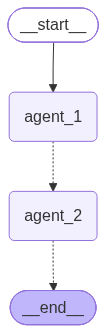

In [3]:
graph